In [1]:
!pip install uproot
""" SECCION IMPORTS """
import uproot
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras.layers as layers
import keras.models as models
import keras.initializers as initializers
from keras import Input
from sklearn.model_selection import train_test_split
import matplotlib.ticker as ticker
from keras.layers import Conv1D
from keras.models import Model
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 37.7 MB/s eta 0:00:00


In [2]:
"""FUNCIONES AUXILIARES"""

def mostrar_estructura_dataset(root_file):
    """
    Muestra la estructura interna de los
    datasets.
    """
    dataset_raw = uproot.open(root_file)
    trees = dataset_raw.keys()
    branches = []
    for tree in trees:
        branches.append(dataset_raw[tree].keys())

    print("root_file")
    for i in range(len(trees)):
        print(f"└── TTree: {trees[i]}")
        print(f"    └── branches: {branches[i]}")

    return dataset_raw

def preparacion_datos(light_dataset_raw, dark_dataset_raw):
    """
    OBJ: Cargar los datasets LIGHT y DARK desde los ficheros ROOT.
    PARAMS:
        light_dataset_raw : (uproot.Dataset) Dataset RAW de pulsos LIGHT.
        dark_dataset_raw : (uproot.Dataset) Dataset RAW de pulsos DARK.
    RETURNS:
        LIGHT_PULSES : (np.ndarray) Pulsos procedentes del dataset LIGHT.
        DARK_PULSES : (np.ndarray) Pulsos procedentes del dataset DARK.
    """

    # Apertura de árboles ROOT
    tree_light_data = light_dataset_raw["alazar_data"]
    tree_light_parameters = light_dataset_raw["alazar_parameters"]
    tree_dark_data = dark_dataset_raw["alazar_data"]
    tree_dark_parameters = dark_dataset_raw["alazar_parameters"]

    # Extracción de pulsos
    LIGHT_PULSES = tree_light_data["dataChA"].array(library="np")
    DARK_PULSES = tree_dark_data["dataChA"].array(library="np")

    # Información de carga
    print("\n======================================")
    print("      PREPARACIÓN DE DATOS")
    print("======================================")

    print("\nDataset LIGHT")
    print(f"\nNúmero de pulsos LIGHT: {LIGHT_PULSES.shape[0]}")
    print(f"Muestras por pulso: {LIGHT_PULSES[0].shape[0]}")

    print("\nDataset DARK")
    print(f"\nNúmero de pulsos DARK: {DARK_PULSES.shape[0]}")
    print(f"Muestras por pulso: {DARK_PULSES[0].shape[0]}")

    print("\nShapes completos:")
    print(f"LIGHT_PULSES.shape = {LIGHT_PULSES.shape}")
    print(f"DARK_PULSES.shape  = {DARK_PULSES.shape}")

    return LIGHT_PULSES, DARK_PULSES


def seleccionar_ventana_muestras(LIGHT_PULSES, DARK_PULSES, n_samples, inicio, fin):
    """
    OBJ: Recorta cada traza en la ventana fija [inicio:fin] y elimina
    el offset de voltaje usando el baseline previo a la ventana.
    PARAMS:
    n_samples  : (int)Número de muestras a recortar.
    inicio  :  (int)Índice de inicio de la ventana (incluido).
    fin     :  (int)Índice de fin de la ventana (excluido).
    RETURN:
    light_pulses  : (np.ndarray) Trazas recortadas con offset eliminado.
    dark_pulses   : (np.ndarray) Trazas recortadas con offset eliminado.
    """
    assert inicio >= 0, "El índice de inicio debe ser >= 0."
    assert fin <= len(LIGHT_PULSES[0]), (
        f"El índice fin ({fin}) supera la longitud de la traza ({len(LIGHT_PULSES[0])})."
    )
    assert fin <= len(DARK_PULSES[0]), (
        f"El índice fin ({fin}) supera la longitud de la traza ({len(DARK_PULSES[0])})."
    )
    assert inicio < fin, "El índice inicio debe ser menor que fin."

    trazas_light = []
    trazas_dark = []
    trazas_light_test = []
    trazas_dark_test = []
    for traza in LIGHT_PULSES[:n_samples]:
        offset = np.mean(traza[:inicio]) if inicio > 0 else 0.0
        trazas_light.append(traza[inicio:fin] - offset)
    for traza in DARK_PULSES[:n_samples]:
        offset = np.mean(traza[:inicio]) if inicio > 0 else 0.0
        trazas_dark.append(traza[inicio:fin] - offset)
    for traza in LIGHT_PULSES[n_samples:]:
        #offset = np.mean(traza[:inicio]) if inicio > 0 else 0.0
        trazas_light_test.append(traza[inicio:fin])
    for traza in DARK_PULSES[n_samples:]:
        #offset = np.mean(traza[:inicio]) if inicio > 0 else 0.0
        trazas_dark_test.append(traza[inicio:fin])

    input_len = fin - inicio
    print(f"Ventana seleccionada: [{inicio}:{fin}]")
    print(f"Longitud de traza resultante: {input_len} muestras "
          f"({input_len / 50:.1f} µs a 50 MHz)")

    return np.array(trazas_light), np.array(trazas_dark), np.array(trazas_light_test), np.array(trazas_dark_test)

def extraer_caracteristicas(pulsos):
  """
  OBJ: Extraer un vector reducido de características para el GMM.
  PARAMS:
      pulsos :(np.ndarray) Conjunto de trazas.
  RETURNS:
      features:(np.ndarray) de forma (N, 3)
  """

  features = []

  """Características:
      - v_min      : amplitud mínima del pulso.
      - tau_rise   : tiempo entre el 10% y el 90% de la amplitud.
      - tau_decay  : tiempo de recuperación desde el mínimo hasta el 10%."""

  for traza in pulsos:

      # Amplitud mínima
      v_min = np.min(traza)
      idx_min = np.argmin(traza)

      # Tiempo de bajada (10% -> 90%)
      flanco_bajada = traza[:idx_min]
      umbral_10 = 0.1 * v_min
      umbral_90 = 0.9 * v_min
      idxs_10 = np.where(flanco_bajada < umbral_10)[0]
      idxs_90 = np.where(flanco_bajada < umbral_90)[0]
      idx_10 = idxs_10[0] if len(idxs_10) > 0 else idx_min
      idx_90 = idxs_90[0] if len(idxs_90) > 0 else idx_min
      tau_rise = idx_90 - idx_10

      # Tiempo de recuperación
      flanco_subida = traza[idx_min:]
      idxs_rec = np.where(flanco_subida > umbral_10)[0]
      idx_rec = idxs_rec[0] if len(idxs_rec) > 0 else len(flanco_subida) - 1
      tau_decay = idx_rec

      features.append([v_min, tau_rise, tau_decay])

  return np.array(features)

from sklearn.preprocessing import StandardScaler

def normalizar_caracteristicas(F_train, F_test=None):
  """
  OBJ:Normalizar las características utilizando únicamente
      las estadísticas del conjunto de entrenamiento.
  PARAMS:
      F_train : (np.ndarray) Características de entrenamiento.
      F_test : (np.ndarray) opcional Características de test.
  RETURNS:
      Si F_test es None: F_train_norm, scaler
      Si F_test no es None: F_train_norm, F_test_norm, scaler
  """

  scaler = StandardScaler()
  F_train_norm = scaler.fit_transform(F_train)
  if F_test is None:
      return F_train_norm, scaler
  F_test_norm = scaler.transform(F_test)

  return F_train_norm, F_test_norm, scaler


In [4]:
from sklearn.mixture import GaussianMixture

def entrenar_gmm_light(F_light_norm):
    """
    Entrena un GMM utilizando únicamente pulsos LIGHT.
    """

    gmm_light = GaussianMixture(
        n_components=5,
        covariance_type="full",
        random_state=42,
        max_iter=200,
        n_init=5
    )

    gmm_light.fit(F_light_norm)

    print("=== GMM-LIGHT ===")
    print(f"Convergencia: {gmm_light.converged_}")
    print(f"Iteraciones : {gmm_light.n_iter_}")

    return gmm_light

In [5]:
from sklearn.mixture import GaussianMixture

def entrenar_gmm_dark(F_dark_norm):
    """
    Entrena un GMM utilizando únicamente pulsos DARK.
    """

    gmm_dark = GaussianMixture(
        n_components=8,
        covariance_type="full",
        random_state=42,
        max_iter=200,
        n_init=8
    )

    gmm_dark.fit(F_dark_norm)

    print("=== GMM-DARK ===")
    print(f"Convergencia: {gmm_dark.converged_}")
    print(f"Iteraciones : {gmm_dark.n_iter_}")

    return gmm_dark

In [6]:
from sklearn.mixture import GaussianMixture
import numpy as np

def entrenar_gmm_both(F_both):
    """
    Entrena un GMM utilizando pulsos LIGHT + DARK.
    """

    """F_both = np.vstack([
        F_light_norm,
        F_dark_norm
    ])"""

    gmm_both = GaussianMixture(
        n_components=10,
        covariance_type="full",
        random_state=42,
        max_iter=200,
        n_init=10
    )

    gmm_both.fit(F_both)

    print("=== GMM-BOTH ===")
    print(f"Convergencia: {gmm_both.converged_}")
    print(f"Iteraciones : {gmm_both.n_iter_}")

    return gmm_both

In [7]:
def comparar_bic(F_train, max_componentes=10):
    """
    OBJ: Compara el criterio BIC para distintos números de gaussianas.

    PARAMS:
        F_train : características normalizadas.
        max_componentes : número máximo de gaussianas a evaluar.
    """

    componentes = range(1, max_componentes + 1)

    bic = []

    for k in componentes:

        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=42,
            n_init=5
        )

        gmm.fit(F_train)

        bic.append(gmm.bic(F_train))

    plt.figure(figsize=(7,5))

    plt.plot(componentes, bic, marker="o")

    plt.xlabel("Número de gaussianas")
    plt.ylabel("BIC")

    plt.title("Selección del número de gaussianas")

    plt.grid(True)

    plt.show()

    mejor_k = componentes[bic.index(min(bic))]

    print(f"Mejor número de gaussianas: {mejor_k}")
    print(f"BIC mínimo: {min(bic):.2f}")

    return bic

In [23]:
def calcular_scores_gmm(gmm, F_light_test, F_dark_test):
    """
    Calcula el score de anomalía para pulsos LIGHT y DARK.

    Score alto = más anómalo.
    """

    scores_light = -gmm.score_samples(F_light_test)
    scores_dark  = -gmm.score_samples(F_dark_test)

    return scores_light, scores_dark

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


def evaluar_gmm(gmm, F_light_test, F_dark_test, nombre_modelo):
    """
    Evalúa un modelo GMM.
    """

    scores_light, scores_dark = calcular_scores_gmm(
        gmm,
        F_light_test,
        F_dark_test
    )

    # ==================================
    # Histograma
    # ==================================

    plt.figure(figsize=(8, 5))

    plt.hist(
        scores_light,
        bins=50,
        density=True,
        alpha=0.6,
        color = "orange",
        label="Light"
    )

    plt.hist(
        scores_dark,
        bins=50,
        density=True,
        alpha=0.6,
        color = "navy",
        label="Dark"
    )

    plt.xlabel("Score de anomalía")
    plt.ylabel("Densidad")
    plt.title(f"{nombre_modelo} - Distribución de scores")

    plt.legend()
    plt.grid(True)

    plt.show()

    # ==================================
    # ROC
    # ==================================
    if nombre_modelo == "GMM-Light":
        scores = np.concatenate([
            scores_light,
            scores_dark # ANOMALÍA
        ])
        y_true = np.concatenate([
            np.zeros(len(scores_light)),
            np.ones(len(scores_dark)) # 1-->ANOMALIA
        ])

    elif nombre_modelo == "GMM-Dark":
        scores = np.concatenate([
            scores_light,# ANOMALÍA
            scores_dark
        ])
        y_true = np.concatenate([
            np.ones(len(scores_light)),# 1-->ANOMALIA
            np.zeros(len(scores_dark))
        ])

    else:
        scores = np.concatenate([
            scores_light,
            scores_dark # ANOMALÍA
        ])
        y_true = np.concatenate([
            np.zeros(len(scores_light)),
            np.ones(len(scores_dark)) # 1-->ANOMALIA
        ])

    fpr, tpr, _ = roc_curve(
        y_true,
        scores
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{nombre_modelo} (AUC={roc_auc:.3f})"
    )

    plt.plot([0, 1], [0, 1], "k--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"ROC - {nombre_modelo}")

    plt.legend()
    plt.grid(True)

    plt.show()

    return {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc
    }

In [26]:
def comparar_gmm(
    resultados_light,
    resultados_dark,
    resultados_both
):
    """
    Compara las ROC de los tres modelos GMM.
    """

    plt.figure(figsize=(8, 6))

    plt.plot(
        resultados_light["fpr"],
        resultados_light["tpr"],
        linewidth=2,
        label=f'GMM-Light (AUC={resultados_light["auc"]:.3f})'
    )

    plt.plot(
        resultados_dark["fpr"],
        resultados_dark["tpr"],
        linewidth=2,
        label=f'GMM-Dark (AUC={resultados_dark["auc"]:.3f})'
    )

    plt.plot(
        resultados_both["fpr"],
        resultados_both["tpr"],
        linewidth=2,
        label=f'GMM-Both (AUC={resultados_both["auc"]:.3f})'
    )

    plt.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=0.8
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("Comparación de modelos GMM")

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [8]:
light_dataset_raw = mostrar_estructura_dataset("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")
dark_dataset_raw = mostrar_estructura_dataset("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")
LIGHT_PULSES, DARK_PULSES = preparacion_datos(light_dataset_raw, dark_dataset_raw)
X_light, X_dark, X_light_test, X_dark_test = seleccionar_ventana_muestras(LIGHT_PULSES, DARK_PULSES,1000, 1200, 2600)

root_file
└── TTree: alazar_data;3
    └── branches: ['samplingFrequency', 'timeStamp', 'startTime', 'DAQ', 'AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'cooldown', 'recharge', 'dataChA', 'triggerChA']
└── TTree: alazar_parameters;1
    └── branches: ['AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'DAQ', 'd_or_s', 'cooldown', 'WP1', 'GBWP1', 'WP2', 'GBWP2', 'samplingFrequency', 'adquisition_type', 'adquisition_time', 'type_of_measurement', 'comments', 'number_of_processors', 'thr_1', 'thr_2', 'PreSamples', 'PostSamples', 'filtered_trigger', 'order_1', 'frequency_1', 'order_2', 'frequency_2', 'save_filtered_data']
root_file
└── TTree: alazar_data;6
    └── branches: ['samplingFrequency', 'timeStamp', 'startTime', 'DAQ', 'AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'cooldown', 'recharge', 'dataChA', 'triggerChA']
└── TTree: alazar_parameters;1
    └── branches: ['AlpsIOVersion', 'AlazarVersion',

In [9]:
F_light = extraer_caracteristicas(X_light)
F_dark  = extraer_caracteristicas(X_dark)
F_both  = np.vstack([F_light, F_dark]) #This is equivalent to concatenation along the first axis after 1-D arrays of shape

In [10]:
F_light_train, F_light_val = train_test_split(F_light,test_size=0.2,random_state=42)
F_dark_train, F_dark_val = train_test_split(F_dark,test_size=0.2,random_state=42)
F_both_train, F_both_val = train_test_split(F_both,test_size=0.2,random_state=42)
#F_both para entrenar y para testing se usará F_light_test F_dark_test

In [18]:
#                                                         normalizar_caracteristicas(F_train,      F_test)
F_light_train_norm, F_light_val_norm, scaler_light = normalizar_caracteristicas(F_light_train, F_light_val) #para GMM LIGHT
F_dark_train_norm, F_dark_val_norm, scaler_dark =  normalizar_caracteristicas(F_dark_train, F_dark_val) #para GMM DARK



In [21]:
F_both_train_norm, F_both_val_norm, scaler_both = normalizar_caracteristicas(F_both_train, F_both_val) #para GMM BOTH

In [22]:
gmm_light = entrenar_gmm_light(F_light_train_norm)
gmm_dark = entrenar_gmm_dark(F_dark_train_norm)
gmm_both = entrenar_gmm_both(F_both_train_norm)

=== GMM-LIGHT ===
Convergencia: True
Iteraciones : 49
=== GMM-DARK ===
Convergencia: True
Iteraciones : 15
=== GMM-BOTH ===
Convergencia: True
Iteraciones : 32


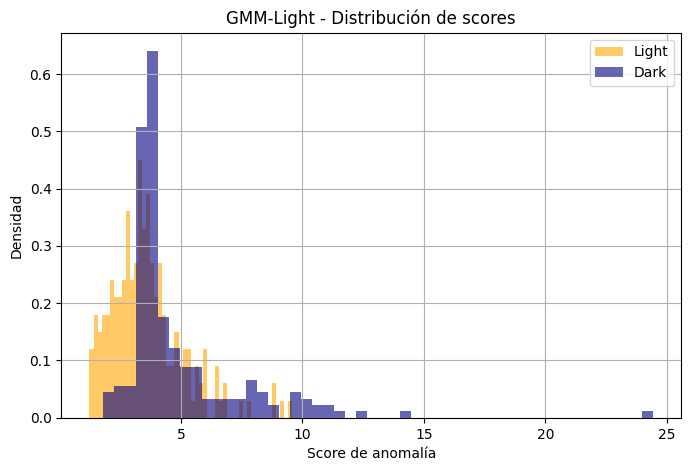

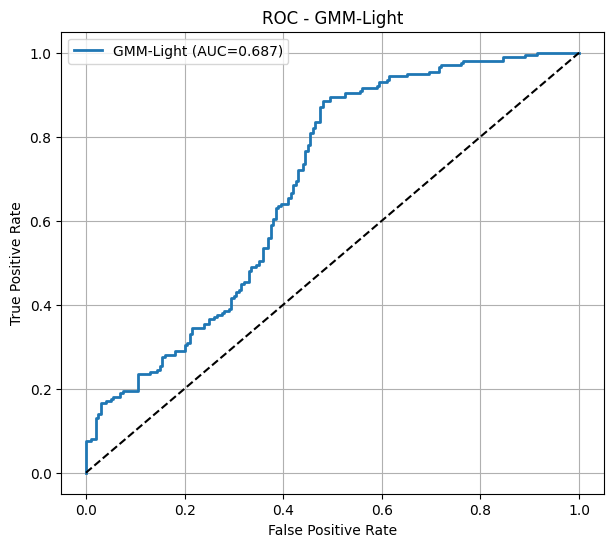

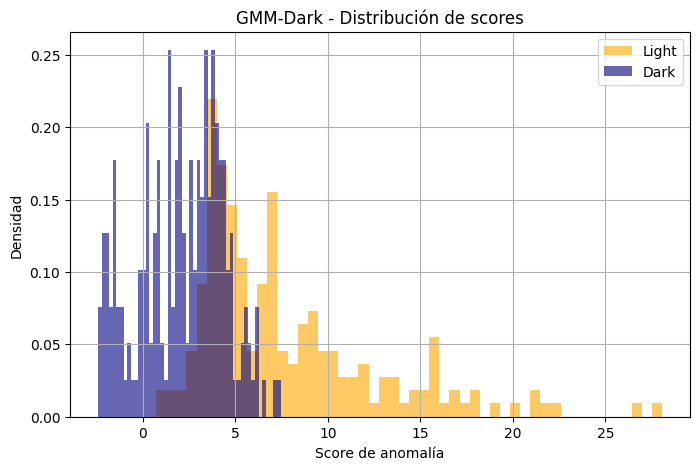

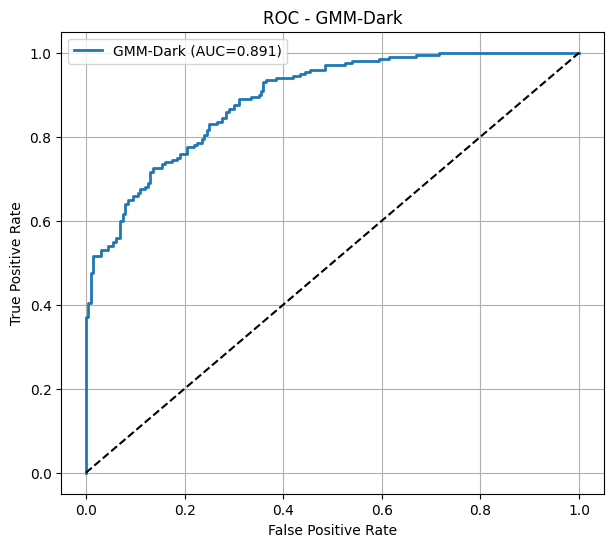

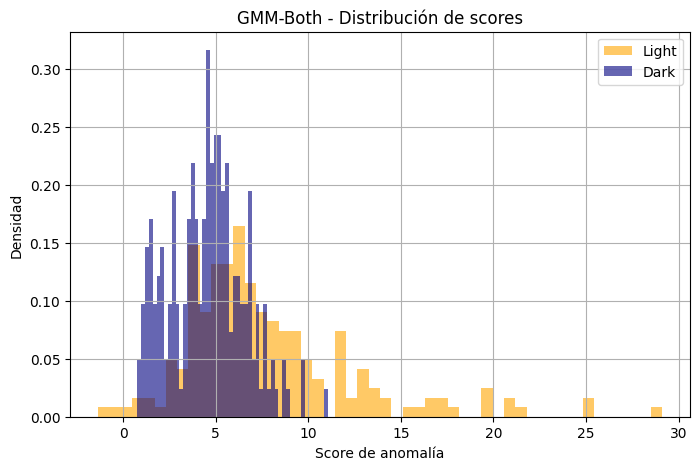

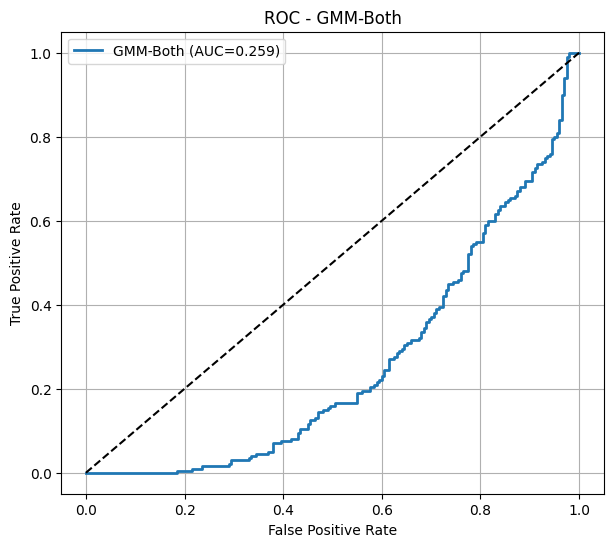

In [24]:
# Evaluación
res_light = evaluar_gmm(gmm_light,F_light_val_norm,F_dark_val_norm,"GMM-Light")
res_dark = evaluar_gmm(gmm_dark,F_light_val_norm,F_dark_val_norm,"GMM-Dark")
res_both = evaluar_gmm(gmm_both,F_light_val_norm,F_dark_val_norm,"GMM-Both")

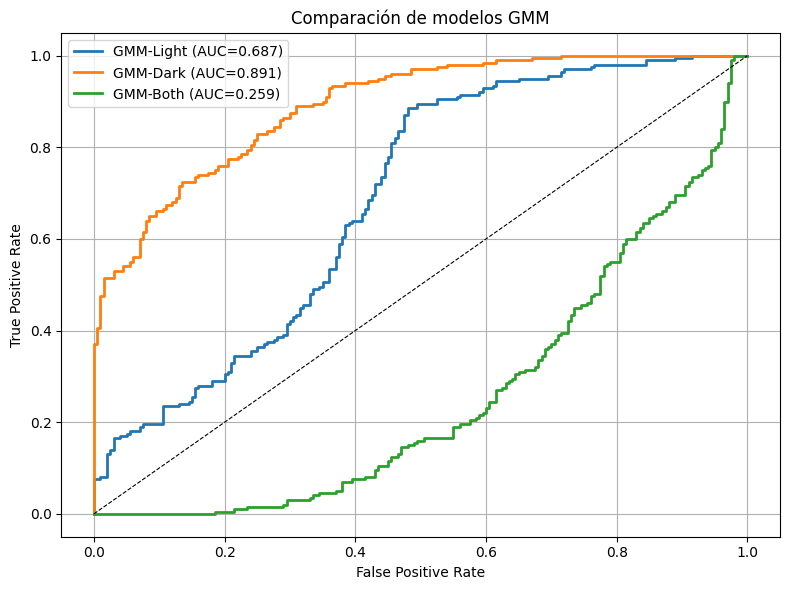

In [27]:
# Comparación final
comparar_gmm(
    res_light,
    res_dark,
    res_both
)

In [28]:
#Función 1: visualizar las gaussianas aprendidas
def visualizar_gaussianas_gmm(gmm, nombres_features=None):

    if nombres_features is None:
        nombres_features = [
            "v_min",
            "tau_rise",
            "tau_decay"
        ]

    medias = gmm.means_[0]
    cov = gmm.covariances_[0]

    print("\n=== PARÁMETROS DEL GMM ===")

    for i, nombre in enumerate(nombres_features):

        sigma = np.sqrt(cov[i, i])

        print(
            f"{nombre:10s} "
            f"μ={medias[i]:8.3f} "
            f"σ={sigma:8.3f}"
        )

    print("\nMatriz de covarianza:")
    print(cov)

In [ ]:
#Función 3: PCA + nube de puntos
def visualizar_pca_gmm(F_light, F_dark):

    X = np.vstack([
        F_light,
        F_dark
    ])

    y = np.concatenate([
        np.zeros(len(F_light)),
        np.ones(len(F_dark))
    ])

    pca = PCA(n_components=2)

    X2 = pca.fit_transform(X)

    plt.figure(figsize=(7,6))

    plt.scatter(
        X2[y==0,0],
        X2[y==0,1],
        s=10,
        alpha=0.4,
        color = "orange",
        label="Light"
    )

    plt.scatter(
        X2[y==1,0],
        X2[y==1,1],
        s=10,
        alpha=0.4,
        color = "blue",
        label="Dark"
    )

    plt.xlabel(
        f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
    )

    plt.ylabel(
        f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
    )

    plt.legend()

    plt.title("Distribución PCA")

    plt.grid(True)

    plt.show()

In [ ]:
def visualizar_scores(
    gmm,
    F_light_test,
    F_dark_test
):

    scores_light = gmm.score_samples(
        F_light_test
    )

    scores_dark = gmm.score_samples(
        F_dark_test
    )

    plt.figure(figsize=(8,5))

    plt.hist(
        scores_light,
        bins=40,
        density=True,
        alpha=0.6,
        color = "orange",
        label="Light"
    )

    plt.hist(
        scores_dark,
        bins=40,
        density=True,
        alpha=0.6,
        color = "navy",
        label="Dark"
    )

    plt.xlabel("Log-verosimilitud")

    plt.ylabel("Densidad")

    plt.title("Distribución de scores")

    plt.legend()

    plt.show()

    print(
        "Media score Light:",
        np.mean(scores_light)
    )

    print(
        "Media score Dark:",
        np.mean(scores_dark)
    )

In [ ]:
visualizar_gaussianas_gmm(gmm_light)
visualizar_gaussianas_gmm(gmm_dark)
visualizar_gaussianas_gmm(gmm_both)


=== PARÁMETROS DEL GMM ===
v_min      μ=  -0.047 σ=   0.946
tau_rise   μ=   0.739 σ=   0.177
tau_decay  μ=   0.252 σ=   1.070

Matriz de covarianza:
[[ 0.89445428 -0.01440904 -0.22827713]
 [-0.01440904  0.03129284  0.00671985]
 [-0.22827713  0.00671985  1.14485843]]

=== PARÁMETROS DEL GMM ===
v_min      μ=   0.608 σ=   0.141
tau_rise   μ=  -0.270 σ=   0.460
tau_decay  μ=  -0.861 σ=   0.202

Matriz de covarianza:
[[ 0.01979193 -0.00877153 -0.00724922]
 [-0.00877153  0.21120442  0.01406162]
 [-0.00724922  0.01406162  0.04063705]]

=== PARÁMETROS DEL GMM ===
v_min      μ=   0.311 σ=   0.346
tau_rise   μ=  -0.191 σ=   0.693
tau_decay  μ=  -0.517 σ=   0.223

Matriz de covarianza:
[[ 0.11945538  0.016857   -0.02692838]
 [ 0.016857    0.47993449  0.0247631 ]
 [-0.02692838  0.0247631   0.04951259]]


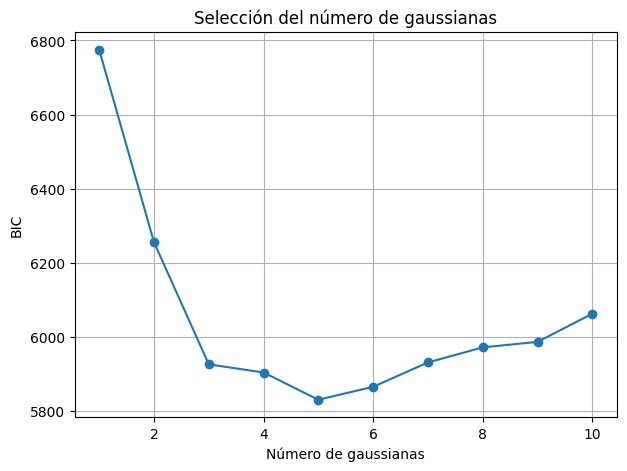

Mejor número de gaussianas: 5
BIC mínimo: 5830.01


[np.float64(6774.939072883263),
 np.float64(6255.26417934118),
 np.float64(5925.551825493764),
 np.float64(5903.500529860064),
 np.float64(5830.011826218114),
 np.float64(5864.893568582936),
 np.float64(5930.704315911709),
 np.float64(5971.3448679449175),
 np.float64(5986.250010684125),
 np.float64(6062.261990364279)]

In [31]:
comparar_bic(F_light_train_norm)

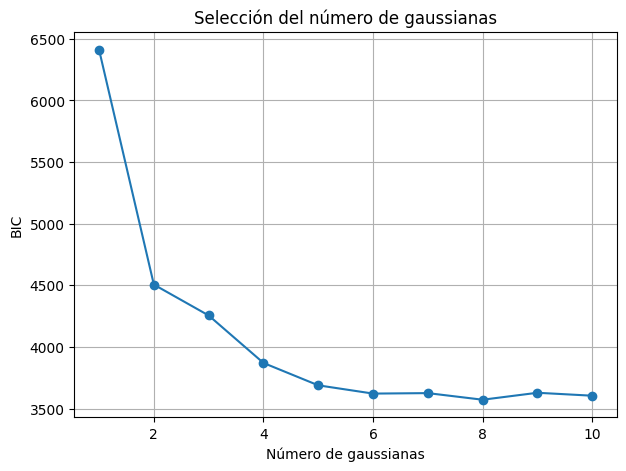

Mejor número de gaussianas: 8
BIC mínimo: 3571.41


[np.float64(6411.685466977383),
 np.float64(4505.683381397908),
 np.float64(4255.268732036669),
 np.float64(3869.8460697615587),
 np.float64(3688.25132746799),
 np.float64(3621.196227593633),
 np.float64(3624.959420477755),
 np.float64(3571.411890557836),
 np.float64(3627.848038299142),
 np.float64(3603.977954781866)]

In [30]:
comparar_bic(F_dark_train_norm)

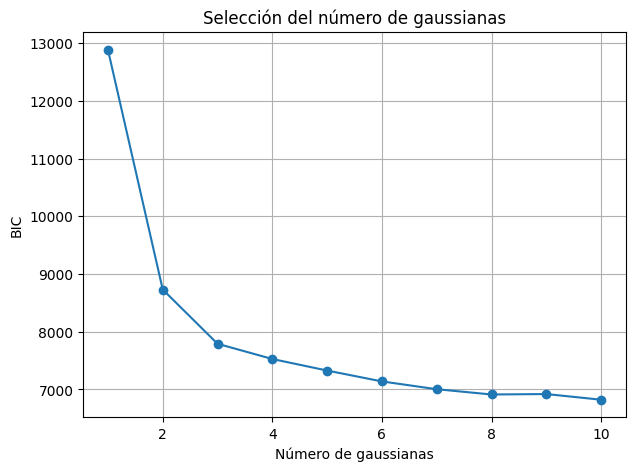

Mejor número de gaussianas: 10
BIC mínimo: 6821.18


[np.float64(12888.546009759368),
 np.float64(8731.110927370317),
 np.float64(7791.146808623641),
 np.float64(7527.01564571815),
 np.float64(7327.008547513699),
 np.float64(7138.350640875942),
 np.float64(7003.405158236267),
 np.float64(6911.911065634953),
 np.float64(6919.364383598747),
 np.float64(6821.178082470512)]

In [29]:
comparar_bic(F_both_train_norm)